In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.data_utils import CancerDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [37]:
x_train, x_test, y_train, y_test = CancerDataHelper.load_dataset(treat_multicol=True)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

Dropped highly correlated feature pairs (|corr| > 0.9):
radius_mean           perimeter_mean          0.997855
perimeter_mean        radius_mean             0.997855
perimeter_worst       radius_worst            0.993708
radius_worst          perimeter_worst         0.993708
radius_mean           area_mean               0.987357
area_mean             radius_mean             0.987357
perimeter_mean        area_mean               0.986507
area_mean             perimeter_mean          0.986507
area_worst            radius_worst            0.984015
radius_worst          area_worst              0.984015
area_worst            perimeter_worst         0.977578
perimeter_worst       area_worst              0.977578
radius_se             perimeter_se            0.972794
perimeter_se          radius_se               0.972794
perimeter_worst       perimeter_mean          0.970387
perimeter_mean        perimeter_worst         0.970387
radius_worst          radius_mean             0.969539
radius_me

((455, 16), (114, 16), (455,), (114,))

In [38]:
x_train.head()

,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
204,0.239073,0.020759,0.398003,0.106758,-0.334557,-0.022424,-0.365099,-0.163371,-0.210966,-0.335675,-0.079647,0.458375,-0.110609,-0.027633,0.164277,0.191312
70,-0.446475,-0.033542,-0.819161,-1.186798,-0.771282,-0.849714,-0.511887,-0.298140,0.333017,-0.810856,-0.784977,-0.573944,-0.137733,-0.020013,-0.571736,-1.015479
131,0.923904,0.329715,0.419294,-0.711643,-0.791834,-0.257521,-0.607101,-0.128431,-0.119485,-0.797656,-0.499931,0.990042,-0.100277,0.505717,-0.117093,-0.216908
431,0.651406,0.503854,-0.006536,1.140753,0.402471,0.982261,0.419284,0.510474,0.001400,0.150305,0.824057,0.564709,0.051487,-0.155256,-0.563788,0.531403
540,0.252698,0.136852,0.018304,0.686873,0.948155,1.691178,0.882319,0.726354,0.535581,-0.266078,0.639879,0.099500,-0.278518,-0.443836,-0.924641,-0.152688


In [39]:
y_train.head()

204    0
70     1
131    1
431    0
540    0
Name: diagnosis_M, dtype: int64

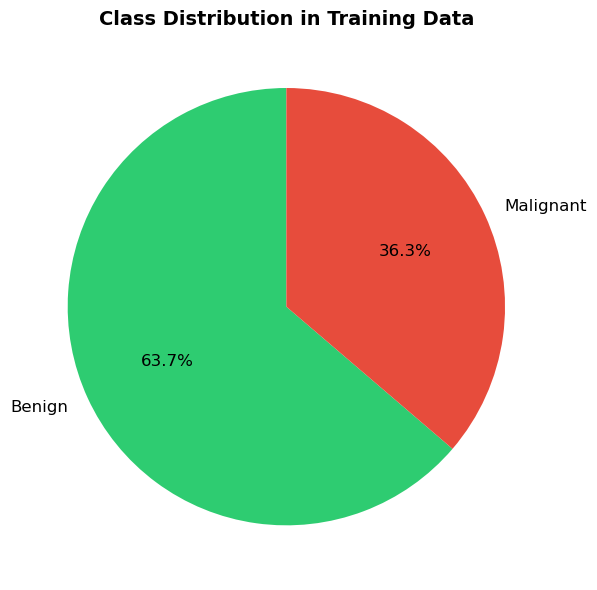

Benign: 290 (63.7%)
Malignant: 165 (36.3%)


In [40]:
CancerDataHelper.plot_outcome_distribution(x_train, y_train)

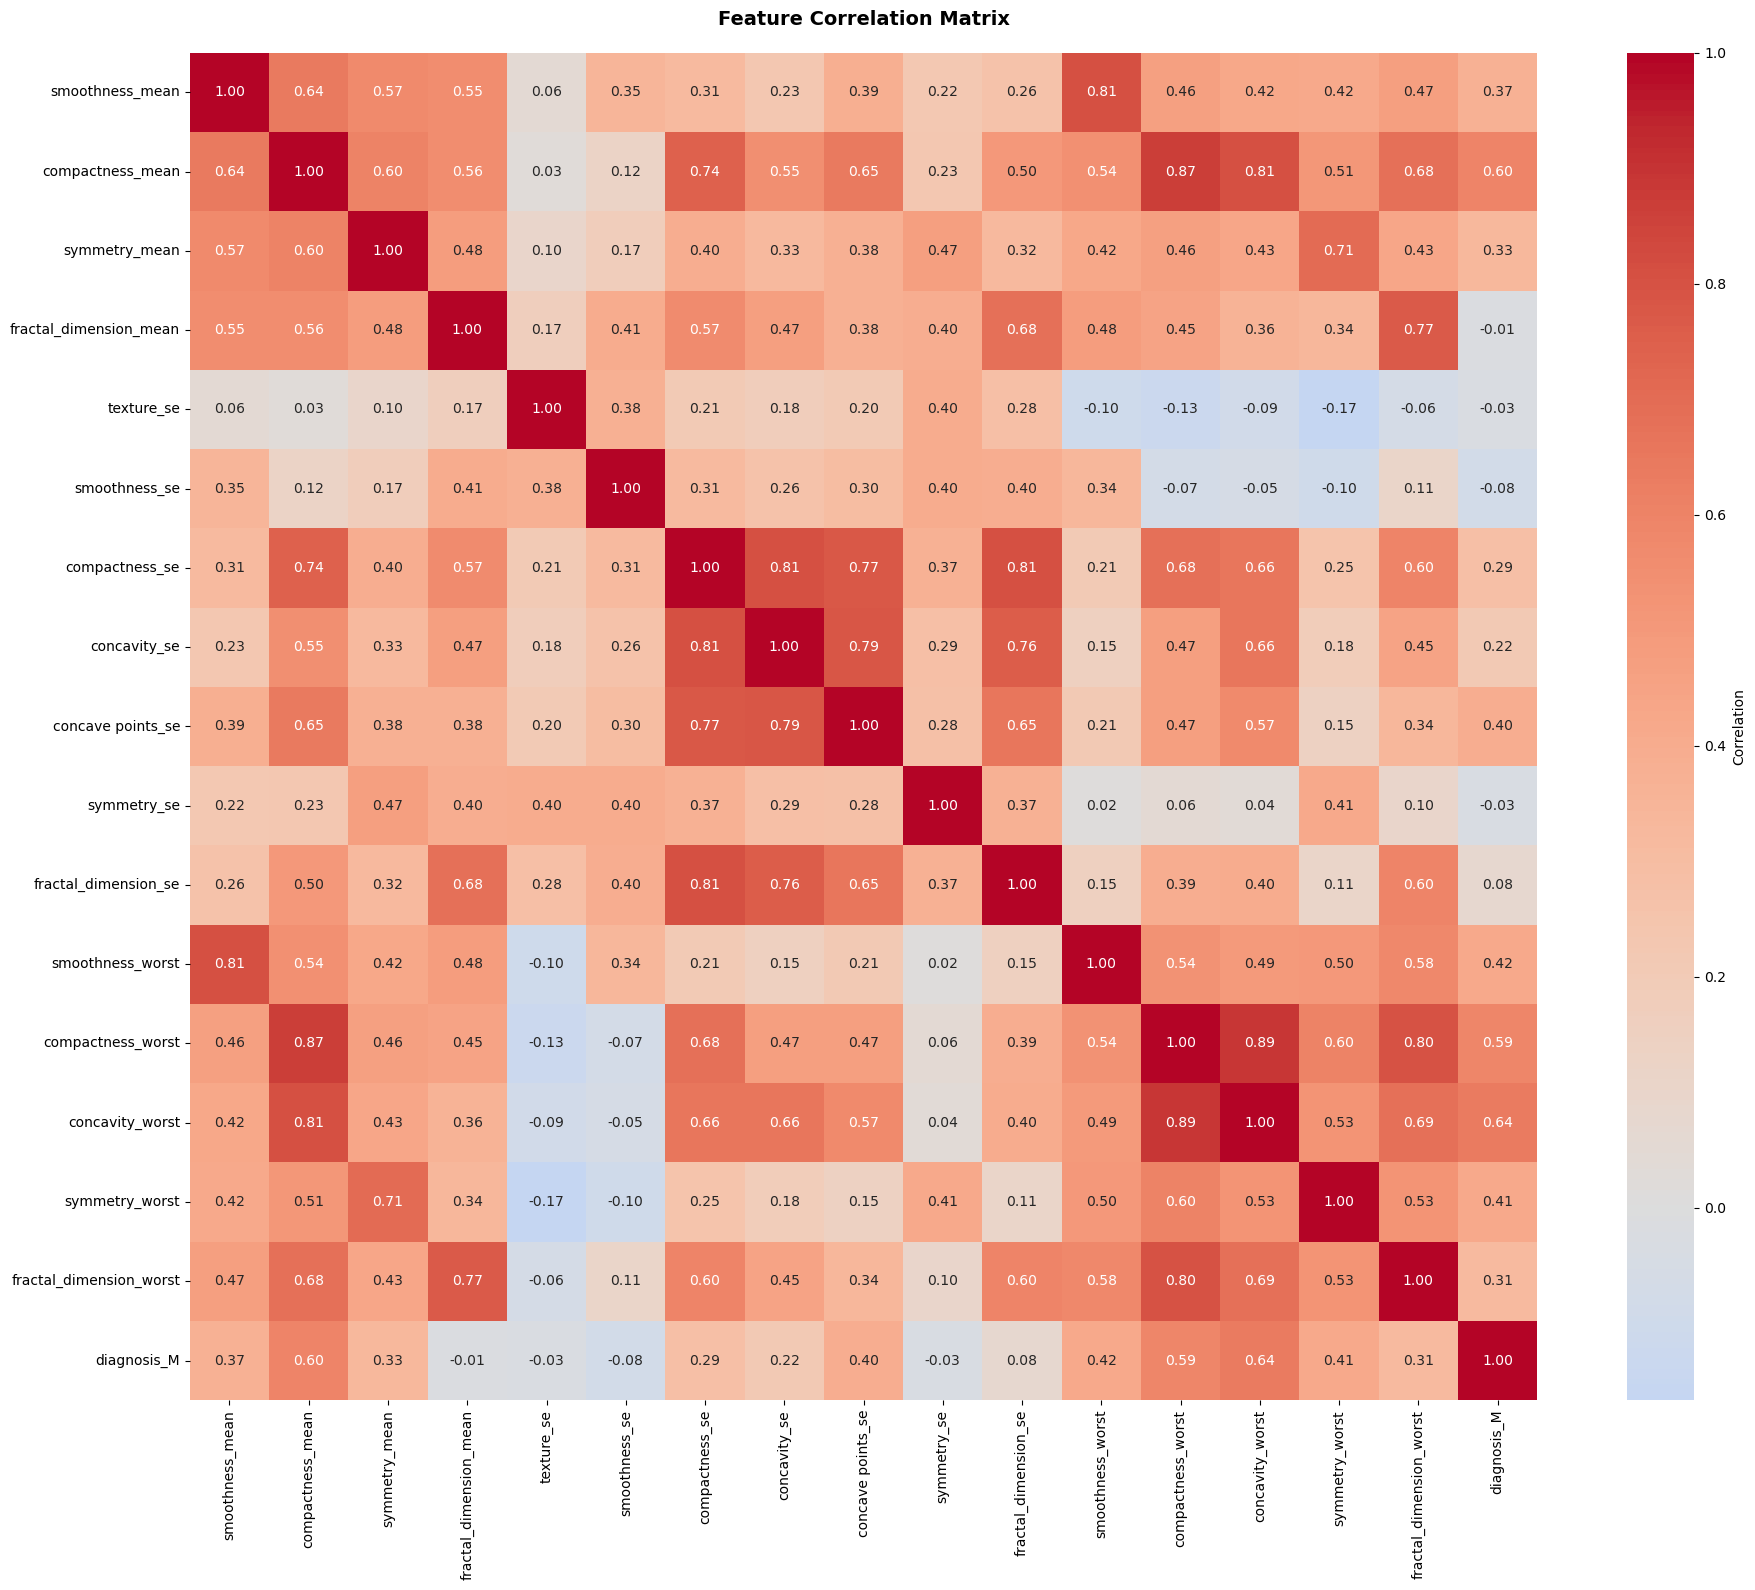

In [41]:
CancerDataHelper.plot_correlation(x_train, y_train)

## Model Training

In [42]:
x_train_np = np.array(x_train)
x_test_np = np.array(x_test)

y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

In [43]:
n_features = x_train_np.shape[1]
weights = np.random.normal(0, np.sqrt(2.0 / n_features), size=(n_features))
bias = 0

weights.shape

(16,)

In [44]:
def sigmoid(linear):
    return 1 / (1 + np.exp(-linear))

In [45]:
def forward(x):
    linear = np.dot(x, weights) + bias
    return sigmoid(linear)

In [46]:
def compute_loss(y_true, prob):
    epsilon = 1e-15
    prob = np.clip(prob, epsilon, 1 - epsilon)
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))
    return loss

In [47]:
def backward(x, prob, y_true, learning_rate=0.01):
    global weights, bias
    
    dw = x * (prob - y_true)
    db = prob - y_true
    
    weights -= dw * learning_rate
    bias -= db * learning_rate
    

In [48]:
epochs = 20_000
epoch_losses = []

learning_rate = 1

for epoch in range(epochs):
    total_loss = 0
    
    for idx in range(len(x_train_np)):
        prob = forward(x_train_np[idx])
        
        loss = compute_loss(y_train_np[idx], prob)
        total_loss += loss
        
        backward(x_train_np[idx], prob, y_train_np[idx], learning_rate)
    
    avg_loss = total_loss / len(x_train_np)
    
    if epoch > 0 and avg_loss >= epoch_losses[-1]:
        learning_rate *= 0.8

    epoch_losses.append(avg_loss)
    
    if (epoch + 1) % 1_000 == 0:
        print(f"Epoch: {epoch + 1}/{epochs} | Avg. Loss: {avg_loss}")

Epoch: 1000/20000 | Avg. Loss: 0.18887268769646004
Epoch: 2000/20000 | Avg. Loss: 0.14397489679215436
Epoch: 3000/20000 | Avg. Loss: 0.14397293622632007
Epoch: 4000/20000 | Avg. Loss: 0.14397293152543586
Epoch: 5000/20000 | Avg. Loss: 0.14397293151347718
Epoch: 6000/20000 | Avg. Loss: 0.14021401856000937
Epoch: 7000/20000 | Avg. Loss: 0.14021390135969516
Epoch: 8000/20000 | Avg. Loss: 0.14021389902604814
Epoch: 9000/20000 | Avg. Loss: 0.1402138989778452
Epoch: 10000/20000 | Avg. Loss: 0.13884098097809863
Epoch: 11000/20000 | Avg. Loss: 0.13884088802111044
Epoch: 12000/20000 | Avg. Loss: 0.1388408822336587
Epoch: 13000/20000 | Avg. Loss: 0.13884088195937666
Epoch: 14000/20000 | Avg. Loss: 0.13884088194709868
Epoch: 15000/20000 | Avg. Loss: 0.13682035804654025
Epoch: 16000/20000 | Avg. Loss: 0.13549521743111598
Epoch: 17000/20000 | Avg. Loss: 0.1346350989146096
Epoch: 18000/20000 | Avg. Loss: 0.13407969859802973
Epoch: 19000/20000 | Avg. Loss: 0.13388098944351567
Epoch: 20000/20000 | Avg

In [49]:
def predict(x):
    prob = forward(x)
    return prob >= 0.5, prob

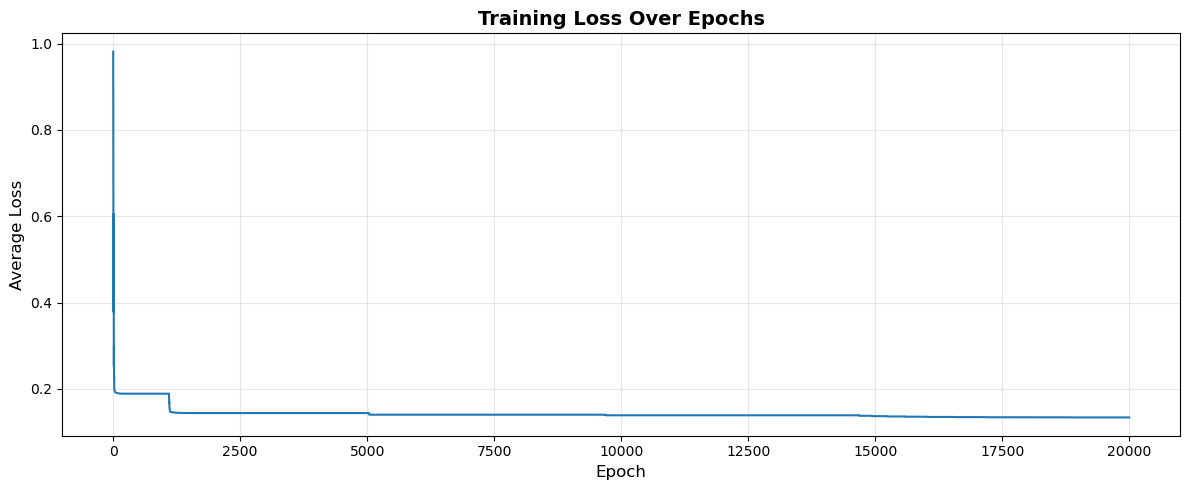

Initial loss: 0.981562
Final loss: 0.133881
Loss reduction: 86.36%


In [50]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epoch_losses, linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Training Loss Over Epochs", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {epoch_losses[0]:.6f}")
print(f"Final loss: {epoch_losses[-1]:.6f}")
print(f"Loss reduction: {(epoch_losses[0] - epoch_losses[-1])/epoch_losses[0]*100:.2f}%")

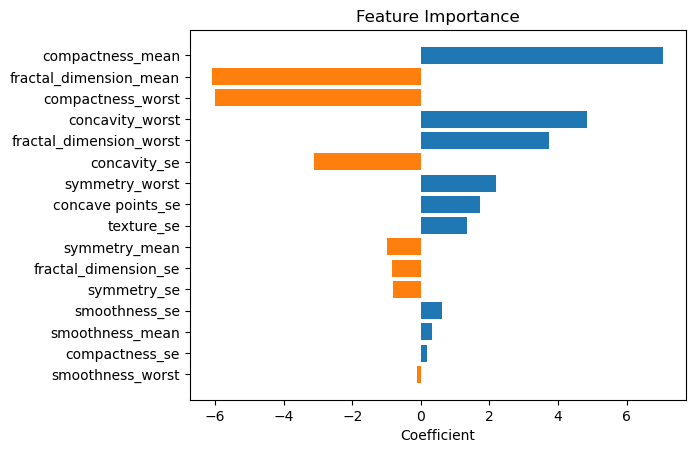

In [51]:
coefs = weights
features = np.array(x_train.columns)

idx = np.argsort(np.abs(coefs))[::-1]

plt.barh(features[idx], coefs[idx], color=["#1f77b4" if c > 0 else "#ff7f0e" for c in coefs[idx]])
plt.xlabel("Coefficient")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Model Evaluation

In [52]:
predictions = []
probabilities = []

for x in x_test_np:
    prediction, prob = predict(x)
    predictions.append(prediction)
    probabilities.append(prob)

predictions = np.array(predictions)
probabilities = np.array(probabilities)

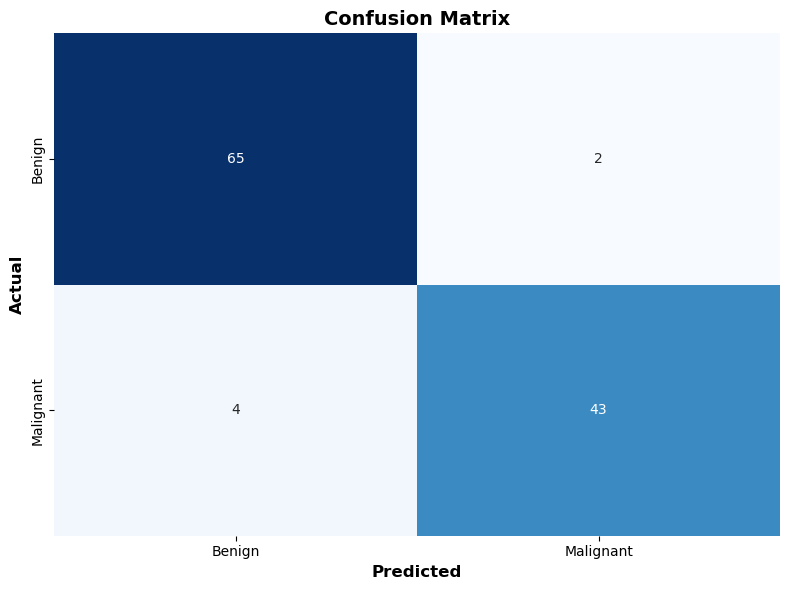

True Negatives: 65
False Positives: 2
False Negatives: 4
True Positives: 43

Sensitivity (Recall): 0.9149
Specificity: 0.9701
Precision: 0.9556
Accuracy: 0.9474
F1 Score: 0.9348


In [53]:
EvaluationHelper.plot_confusion_matrix(y_test_np, predictions, class_names=["Benign", "Malignant"])

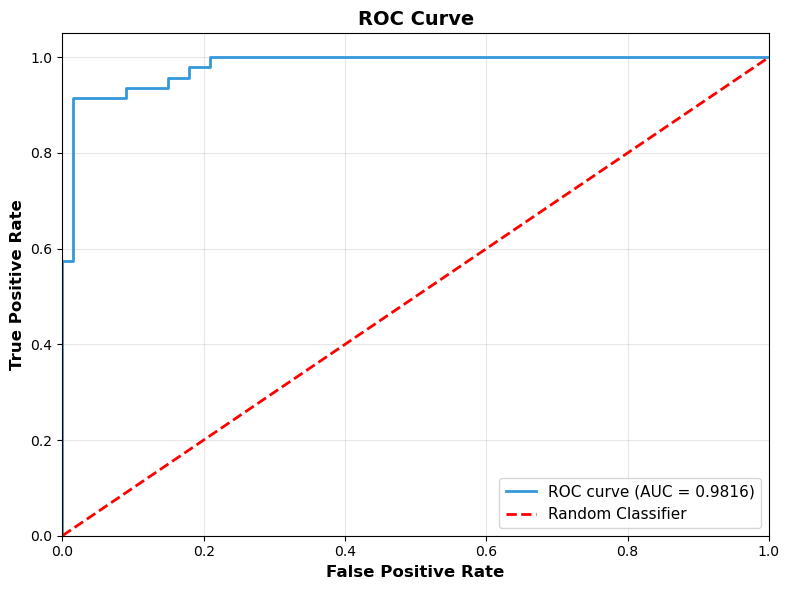

Area Under the Curve (AUC): 0.9816


In [54]:
EvaluationHelper.plot_roc_curve(y_test_np, probabilities)

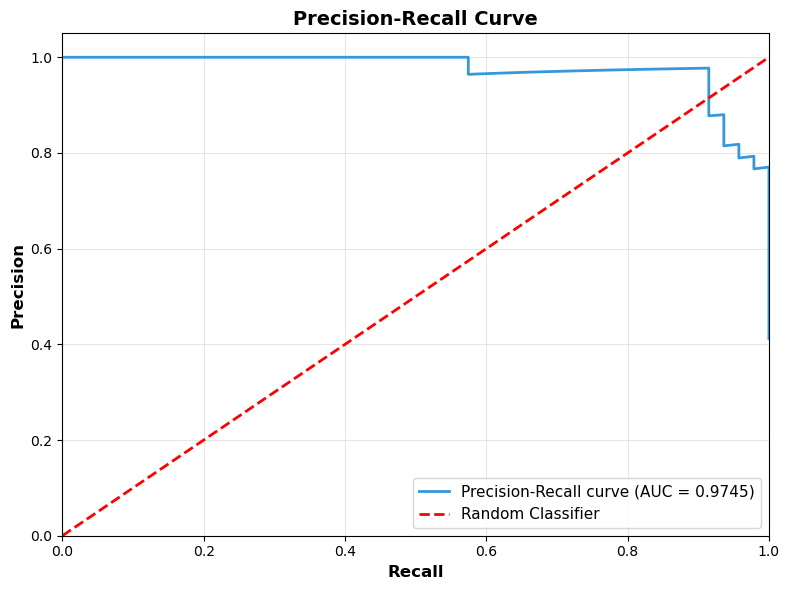

Area Under the Curve (AUC): 0.9745


In [55]:
EvaluationHelper.plot_precision_recall_curve(y_test_np, probabilities)